<a href="https://colab.research.google.com/github/Sherzod19s/Hospital-Patients-Records-Case-Study/blob/main/Hospital_Patients_Records.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hospital Patients Records Case Study

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
encounters = pd.read_csv('encounters.csv')
procedures = pd.read_csv('procedures.csv')
payers = pd.read_csv('payers.csv')
patients = pd.read_csv('patients.csv')
org = pd.read_csv('organizations.csv')

In [4]:
encounters.columns

Index(['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PAYER',
       'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
       'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE',
       'REASONDESCRIPTION'],
      dtype='object')

In [5]:
encounters.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:32:11Z,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03T16:24:45Z,2011-01-03T16:39:45Z,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03T17:36:53Z,2011-01-03T17:51:53Z,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia


In [6]:
encounters['year'] = pd.to_datetime(encounters['START']).dt.year

# OBJECTIVE 1: ENCOUNTERS OVERVIEW

### a. How many total encounters occurred each year?

In [87]:
encounters.groupby('year').size().reset_index(name='Total').sort_values(['year','Total'], ascending=[False,False])

,year,Total
11,2022,220
10,2021,3530
9,2020,2519
8,2019,2228
7,2018,2292
6,2017,2360
5,2016,2451
4,2015,2469
3,2014,3885
2,2013,2495


### b. For each year, what percentage of all encounters belonged to each encounter class (ambulatory, outpatient, wellness, urgent care, emergency, and inpatient)?

In [8]:
encounters['ENCOUNTERCLASS'].unique()

array(['ambulatory', 'outpatient', 'wellness', 'urgentcare', 'inpatient',
       'emergency'], dtype=object)

In [9]:
encounters.groupby('ENCOUNTERCLASS')['year'].size().reset_index(name='Total')

,ENCOUNTERCLASS,Total
0,ambulatory,12537
1,emergency,2322
2,inpatient,1135
3,outpatient,6300
4,urgentcare,3666
5,wellness,1931


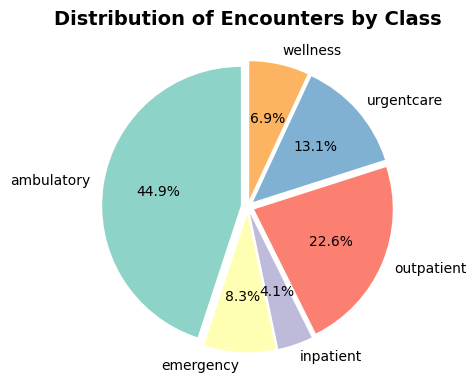

In [104]:
data = {
    'ENCOUNTERCLASS': ['ambulatory', 'emergency', 'inpatient', 'outpatient', 'urgentcare', 'wellness'],
    'Total': [12537, 2322, 1135, 6300, 3666, 1931]
}
df = pd.DataFrame(data)

plt.figure(figsize=(6, 4))
colors = sns.color_palette('Set3', n_colors=len(df))
plt.pie(df['Total'], labels=df['ENCOUNTERCLASS'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=[0.05]*len(df))
plt.title('Distribution of Encounters by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

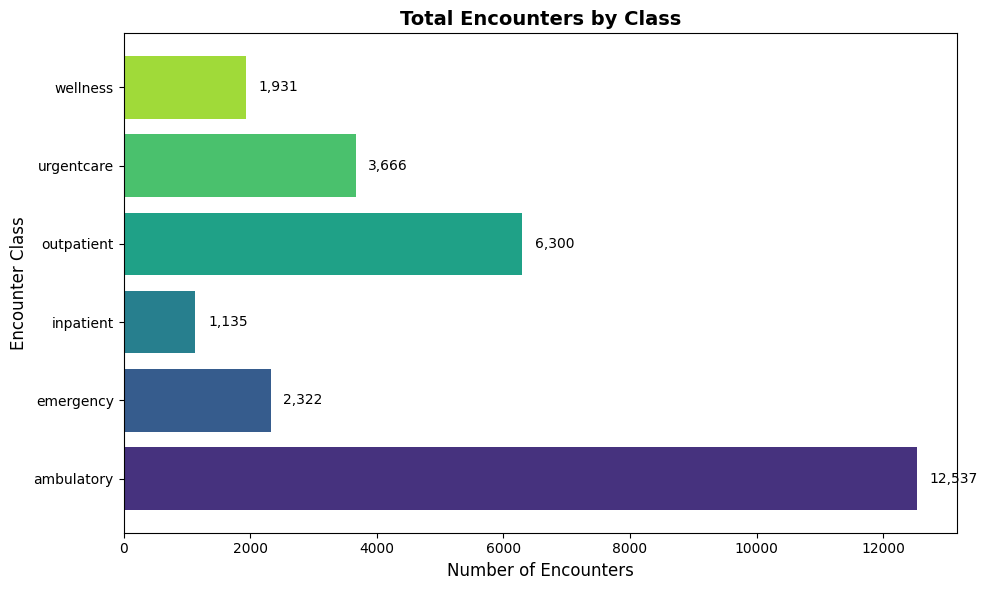

## c. What percentage of encounters were over 24 hours versus under 24 hours?

In [10]:
# Convert to datetime first
encounters['START'] = pd.to_datetime(encounters['START'])
encounters['STOP'] = pd.to_datetime(encounters['STOP'])

In [11]:
# Calculate duration in hours
encounters['duration_hours'] = (encounters['STOP'] - encounters['START']).dt.total_seconds() / 3600

In [12]:
# Categorize as over or under 24 hours
encounters['duration_category'] = encounters['duration_hours'].apply(lambda x: 'over_24h' if x > 24 else 'under_24h')

In [13]:
# Calculate percentages
duration_pct = (encounters['duration_category']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
duration_pct.columns = ['duration_category', 'percentage']

In [14]:
duration_pct

,duration_category,percentage
0,under_24h,99.73
1,over_24h,0.27


# OBJECTIVE 2: COST & COVERAGE INSIGHTS

### How many encounters had zero payer coverage, and what percentage of total encounters does this represent?

In [15]:
zero_coverage = (encounters['PAYER_COVERAGE']==0).sum()
print(f"zero_coverage: {zero_coverage} encounters")

zero_coverage: 13586 encounters


In [16]:
total = len(encounters)
print(f"Total {total} zero coverage encounters")

Total 27891 zero coverage encounters


In [17]:
perc = round(zero_coverage/total *100, 2)
print(f"{perc} % of total encounters")

48.71 % of total encounters


### b. What are the top 10 most frequent procedures performed and the average base cost for each?

In [18]:
procedures.columns

Index(['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION',
       'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION'],
      dtype='object')

In [80]:
procedures.groupby('DESCRIPTION').agg(Num_procedures =('BASE_COST', 'size'),
       Avg_cost = ('BASE_COST', 'mean')).sort_values('Num_procedures', ascending=False).round(2).reset_index().head(10)

,DESCRIPTION,Num_procedures,Avg_cost
0,Assessment of health and social care needs (pr...,4596,431.00
1,Hospice care (regime/therapy),4098,431.00
2,Depression screening using Patient Health Ques...,3614,431.00
3,Depression screening (procedure),3614,431.00
4,Assessment of substance use (procedure),2906,431.00
5,Renal dialysis (procedure),2746,1004.09
6,Assessment using Morse Fall Scale (procedure),2422,431.00
7,Assessment of anxiety (procedure),2288,431.00
8,Medication Reconciliation (procedure),2284,509.12
9,Screening for drug abuse (procedure),1484,431.00


### c. What are the top 10 procedures with the highest average base cost and the number of times they were performed?

In [79]:
procedures.groupby('DESCRIPTION').agg(Num_procedures =('BASE_COST', 'size'),
       Avg_cost = ('BASE_COST', 'mean')).sort_values('Avg_cost', ascending=False).round(2).reset_index().head(10)

,DESCRIPTION,Num_procedures,Avg_cost
0,Admit to ICU (procedure),5,206260.40
1,Coronary artery bypass grafting,9,47085.89
2,Lumpectomy of breast (procedure),5,29353.00
3,Hemodialysis (procedure),27,29299.56
4,Insertion of biventricular implantable cardiov...,4,27201.00
5,Electrical cardioversion,1383,25903.11
6,Partial resection of colon,7,25229.29
7,Fine needle aspiration biopsy of lung (procedure),1,23141.00
8,Percutaneous mechanical thrombectomy of portal...,57,20228.04
9,Percutaneous coronary intervention,9,19728.00


### d. What is the average total claim cost for encounters, broken down by payer?

In [42]:
encounters.groupby('PAYER')['TOTAL_CLAIM_COST'].mean().round(2).sort_values(ascending=False).reset_index()

,PAYER,TOTAL_CLAIM_COST
0,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,6205.22
1,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,5593.20
2,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,4236.81
3,d47b3510-2895-3b70-9897-342d681c769d,3269.30
4,6e2f1a2d-27bd-3701-8d08-dae202c58632,3245.58
5,047f6ec3-6215-35eb-9608-f9dda363a44c,2996.95
6,5059a55e-5d6e-34d1-b6cb-d83d16e57bcf,2848.34
7,4d71f845-a6a9-3c39-b242-14d25ef86a8d,2767.05
8,7caa7254-5050-3b5e-9eae-bd5ea30e809c,2167.55
9,b3221cfc-24fb-339e-823d-bc4136cbc4ed,1696.19


/tmp/ipykernel_658/305841034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='PAYER', x='TOTAL_CLAIM_COST', palette='viridis')


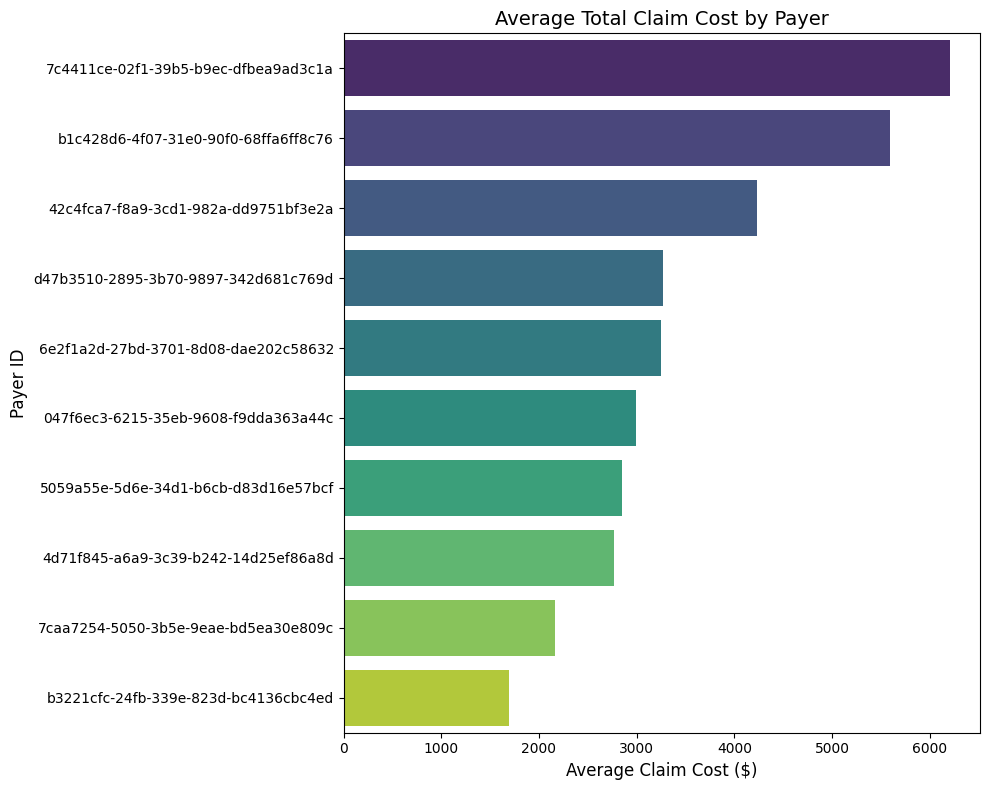

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your data
df = encounters.groupby('PAYER')['TOTAL_CLAIM_COST'].mean().round(2).sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=df, y='PAYER', x='TOTAL_CLAIM_COST', palette='viridis')
plt.title('Average Total Claim Cost by Payer', fontsize=14)
plt.xlabel('Average Claim Cost ($)', fontsize=12)
plt.ylabel('Payer ID', fontsize=12)
plt.tight_layout()
plt.show()

# OBJECTIVE 3: PATIENT BEHAVIOR ANALYSIS

### a. How many unique patients were admitted each quarter over time?

In [49]:
encounters.columns

Index(['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PAYER',
       'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
       'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION',
       'year', 'duration_hours', 'duration_category', 'quarter'],
      dtype='object')

In [48]:
encounters['quarter'] = pd.to_datetime(encounters['START']).dt.quarter

In [71]:
encounters.groupby(['year','quarter'])['PATIENT'].nunique().reset_index().sort_values(['year', 'quarter'], ascending=[True, True])

,year,quarter,PATIENT
0,2011,1,156
1,2011,2,162
2,2011,3,155
3,2011,4,168
4,2012,1,249
5,2012,2,261
6,2012,3,232
7,2012,4,240
8,2013,1,243
9,2013,2,271


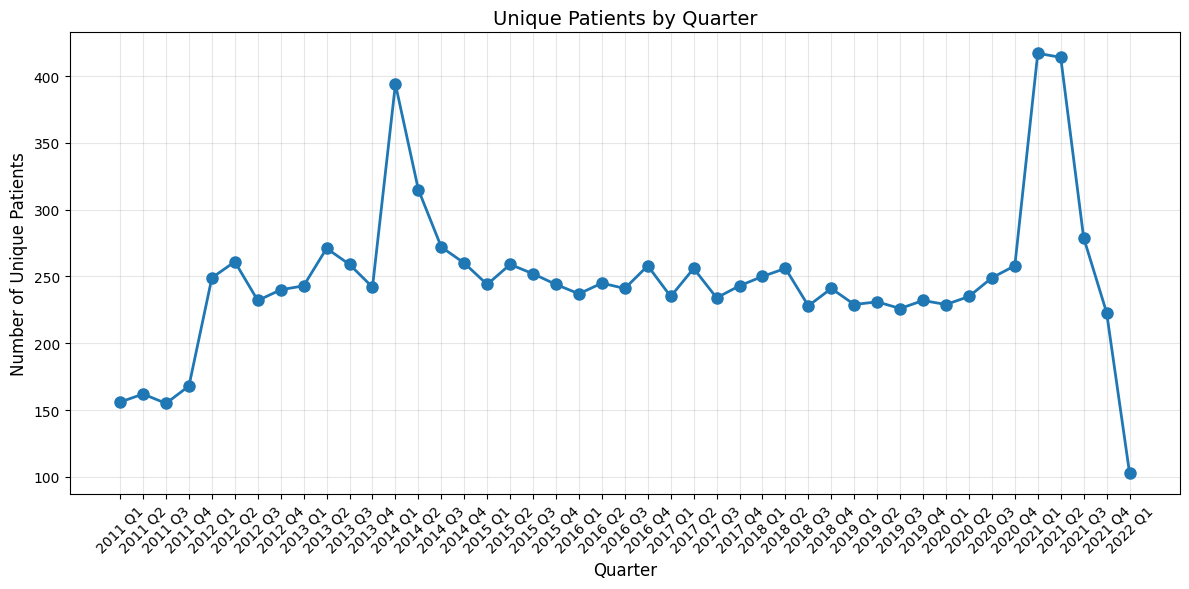

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
df = encounters.groupby(['year','quarter'])['PATIENT'].nunique().reset_index()
df['period'] = df['year'].astype(str) + ' Q' + df['quarter'].astype(str)

# Line plot
plt.figure(figsize=(12, 6))
plt.plot(df['period'], df['PATIENT'], marker='o', linewidth=2, markersize=8)
plt.title('Unique Patients by Quarter', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Number of Unique Patients', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_658/3215710577.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='period', y='PATIENT', palette='viridis')


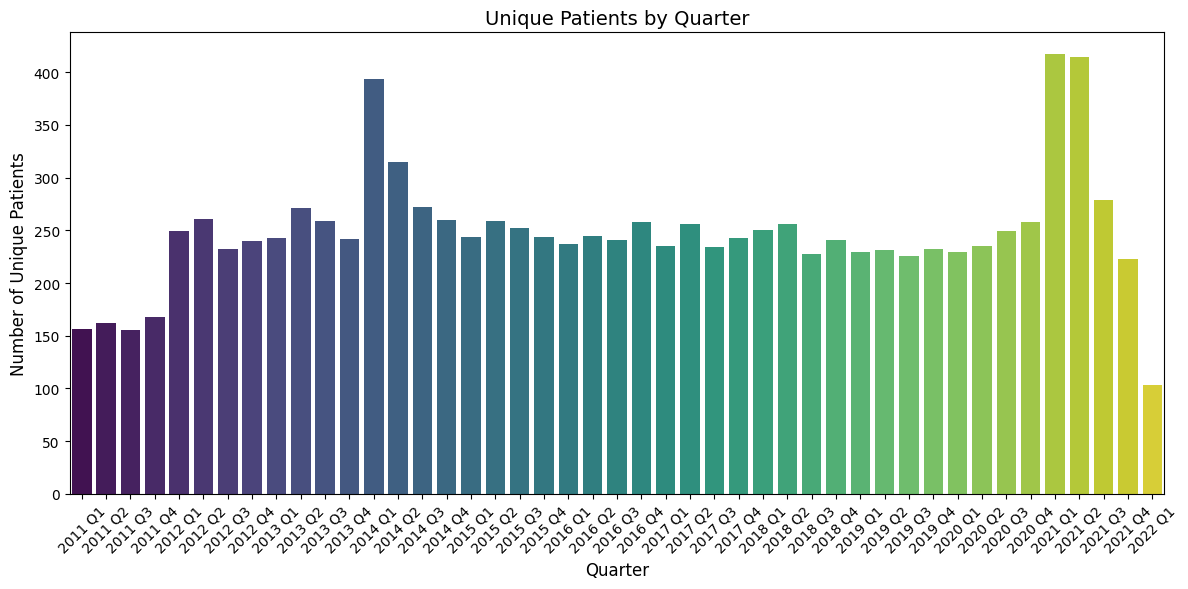

In [73]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='period', y='PATIENT', palette='viridis')
plt.title('Unique Patients by Quarter', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Number of Unique Patients', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

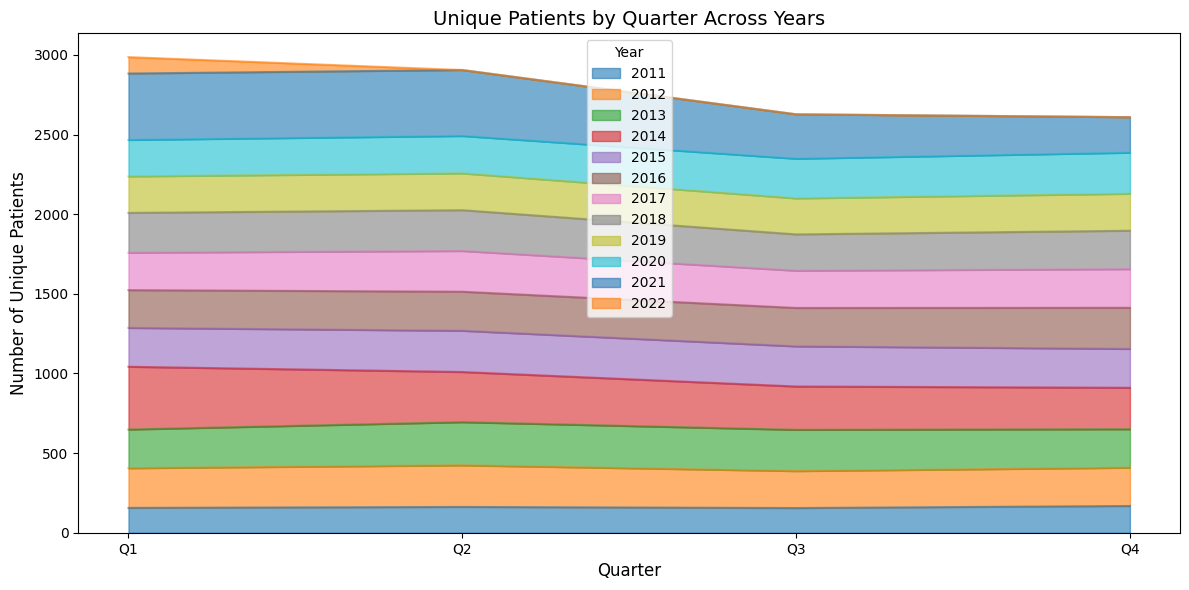

In [75]:
pivot_df = df.pivot(index='quarter', columns='year', values='PATIENT')

pivot_df.plot(kind='area', figsize=(12, 6), alpha=0.6)
plt.title('Unique Patients by Quarter Across Years', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Number of Unique Patients', fontsize=12)
plt.legend(title='Year')
plt.xticks(range(1, 5), ['Q1', 'Q2', 'Q3', 'Q4'])
plt.tight_layout()
plt.show()

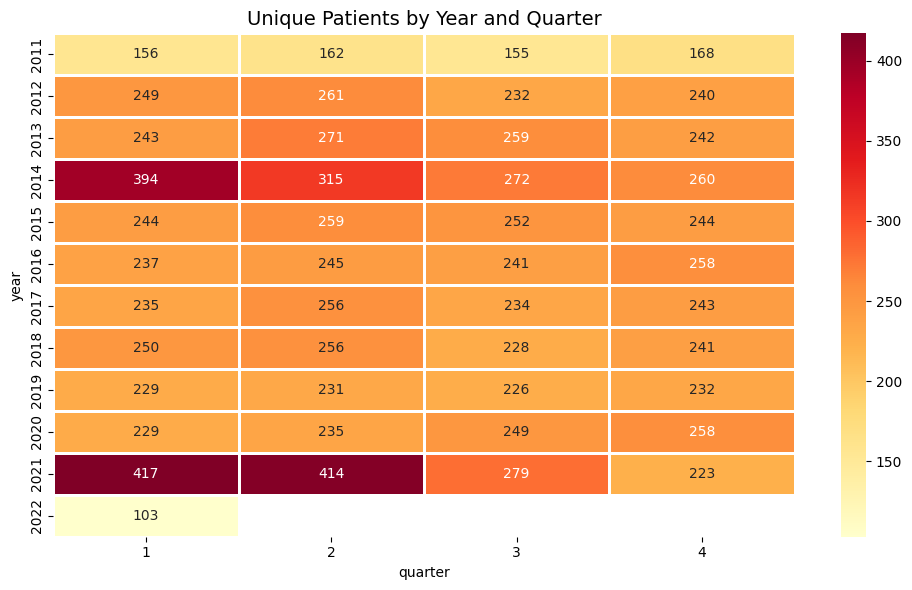

In [76]:
pivot_df = df.pivot(index='year', columns='quarter', values='PATIENT')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=1)
plt.title('Unique Patients by Year and Quarter', fontsize=14)
plt.tight_layout()
plt.show()

### b. How many patients were readmitted within 30 days of a previous encounter?

In [94]:
encounters['START'] = pd.to_datetime(encounters['START'])
encounters_sorted = encounters.sort_values(['PATIENT', 'START'])
encounters_sorted['days_since_prev'] = encounters_sorted.groupby('PATIENT')['START'].diff().dt.days
readmissions = (encounters_sorted['days_since_prev'] <= 30).sum()
patients_readmitted = encounters_sorted[encounters_sorted['days_since_prev'] <= 30]['PATIENT'].nunique()

print(f"Total readmissions within 30 days: {readmissions}")
print(f"Unique patients readmitted: {patients_readmitted}")

Total readmissions within 30 days: 17366
Unique patients readmitted: 772


### c. Which patients had the most readmissions?

In [95]:
readmission_counts = (
    encounters_sorted[encounters_sorted['days_since_prev'] <= 30]
    .groupby('PATIENT')
    .size()
    .reset_index(name='readmission_count')
    .sort_values('readmission_count', ascending=False)
    .head(10)
)

print(readmission_counts)

                                  PATIENT  readmission_count
70   1712d26d-822d-1e3a-2267-0a9dba31d7c8               1376
187  3de74169-7f67-9304-91d4-757e0f3a14d2                876
299  5e055638-0dad-dfd5-005d-1e74b6fd29ac                871
192  3f523789-55f3-bb31-2757-4803ca6a9c2a                442
298  5dcb295d-92df-a147-ebcc-aa49b6262830                421
218  442dc617-c7f2-0513-15cd-c35c4efdba73                384
555  b4ab9ab3-f52a-751e-a990-3bd5654d5870                376
485  9b8ae606-5059-b3a6-19c7-c812901898bb                347
554  b4671e80-7e87-9260-ca31-6a9397d465d1                291
771  ff331e5c-ab16-e218-f39a-63e11de1ed75                280


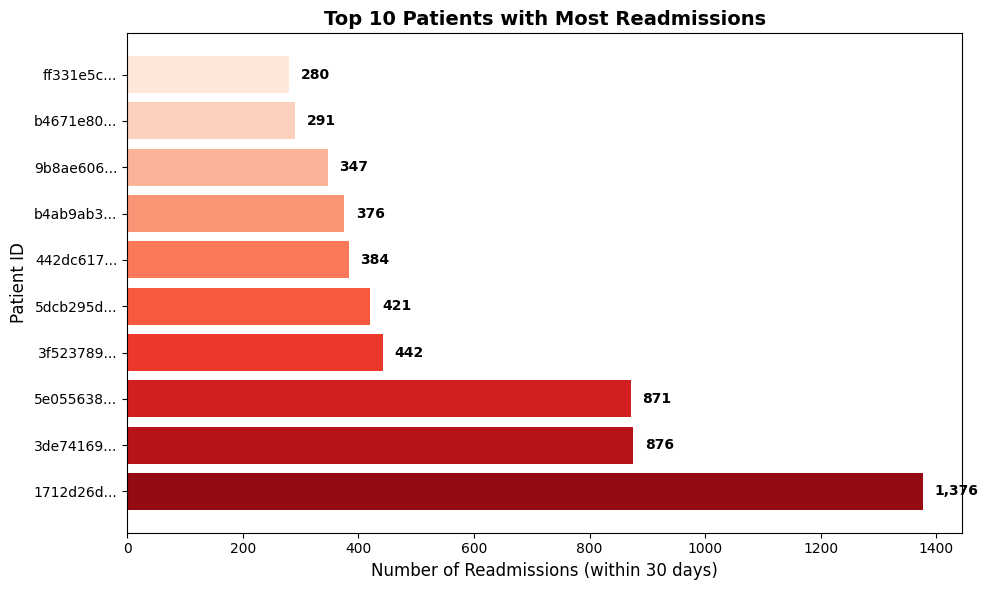

In [98]:
# Create abbreviated patient IDs for display
readmission_counts['PATIENT_short'] = readmission_counts['PATIENT'].str[:8] + '...'

plt.figure(figsize=(10, 6))
colors = sns.color_palette('Reds_r', n_colors=len(readmission_counts))
bars = plt.barh(readmission_counts['PATIENT_short'],
                readmission_counts['readmission_count'],
                color=colors)
plt.xlabel('Number of Readmissions (within 30 days)', fontsize=12)
plt.ylabel('Patient ID', fontsize=12)
plt.title('Top 10 Patients with Most Readmissions', fontsize=14, fontweight='bold')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()